In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [5]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_or_test = []
for i in range(len(df)):
    if df['fragment'][i] in val_texts:
        train_or_test.append(0)
    else:
        train_or_test.append(1)

df['train_or_test'] = train_or_test
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1,0
2,На каждой двери красные плакаты и красные фона...,1,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6,1
7320,Mapillary использует программное обеспечение д...,6,6,1


In [7]:
model_name = 'ai-forever/sbert_large_nlu_ru'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [8]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

In [9]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions

# A/B/C

In [10]:
df_level1 = df.copy()
df_level1['label'] = df_level1['label'].map({1: 0, 2: 0, 3:1, 4:1, 5:2, 6:2})
df_level1

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,2,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,2,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,2,1
7320,Mapillary использует программное обеспечение д...,6,2,1


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label={0: 'A', 1: 'B', 2: 'C'},
    label2id={'A': 0, 'B': 1, 'C': 2}
)

model = model.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [12]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_level1)):
    if df_level1['train_or_test'][i] == 1:
        train_texts.append(df_level1['fragment'][i])
        train_labels.append(df_level1['label'][i])
    else:
        val_texts.append(df_level1['fragment'][i])
        val_labels.append(df_level1['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5833
Валидационная выборка: 1489


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [14]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.559300,0.613754
2,0.294600,0.808254
3,0.109700,1.029427


Обучение завершено за 589.95 секунд (0:09:49)


In [15]:
true_labels, predictions = evaluate_model(model, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.7555
F1 Micro: 0.7555
F1 Macro: 0.7401
F1 Weighted: 0.7587
MAE: 0.2471


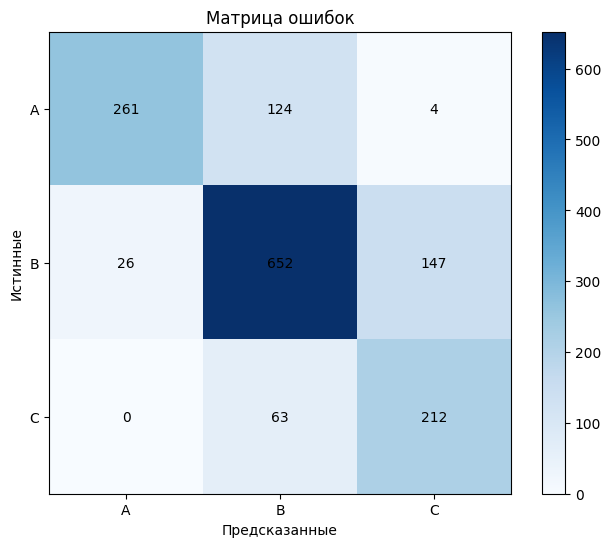

In [16]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(['A', 'B', 'C'])
ax.set_yticklabels(['A', 'B', 'C'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [17]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.7555
0.7555
0.7401
0.7587
0.2471
589.95


# A1/A2

In [18]:
df_A = df.copy()
df_A = df_A[df_A['label'] <=2]
df_A['label'] = df_A['label'].map({1: 0, 2: 1})
df_A

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
1894,"В самом деле, мне очень жалко, что у людей ест...",2,1,1
1895,"Я думаю, что счастлива баллов на 8. Если бы у ...",2,1,1
1896,"У́тром пьём крепкий кофе или чай, потому что м...",2,1,0
1897,Я был там с девушкой. Мы спали в лесу в палатк...,2,1,1


In [19]:
model_A = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'A1', 1: 'A2'},
    label2id={'A1': 0, 'A2': 1}
)

model_A = model_A.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [20]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_A)):
    if df_A['train_or_test'][i] == 1:
        train_texts.append(df_A['fragment'][i])
        train_labels.append(df_A['label'][i])
        
    else:
        val_texts.append(df_A['fragment'][i])
        val_labels.append(df_A['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 1510
Валидационная выборка: 389


In [21]:
trainer = Trainer(
    model=model_A,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [22]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.615500,0.447883
2,0.278000,0.437158
3,0.090500,0.662305


Обучение завершено за 165.65 секунд (0:02:45)


In [23]:
true_labels, predictions = evaluate_model(model_A, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.8458
F1 Micro: 0.8458
F1 Macro: 0.8384
F1 Weighted: 0.8458
MAE: 0.1542


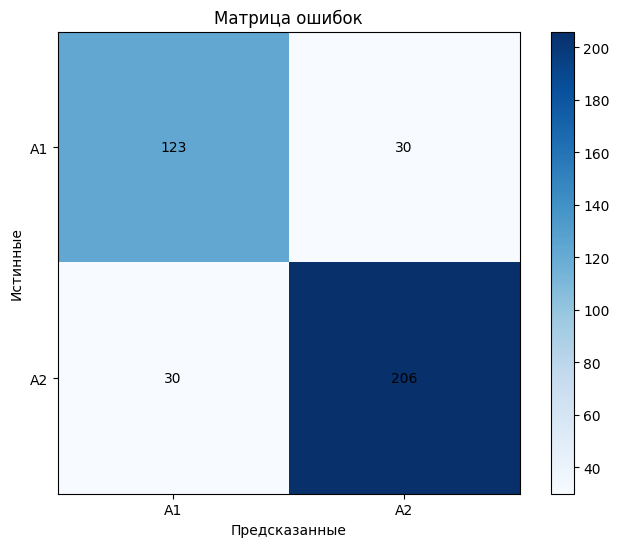

In [24]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['A1', 'A2'])
ax.set_yticklabels(['A1', 'A2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [25]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.8458
0.8458
0.8384
0.8458
0.1542
165.65


# B1/B2

In [26]:
df_B = df.copy()
df_B = df_B[(df_B['label'] <= 4) & (df_B['label'] >= 3)]
df_B['label'] = df_B['label'].map({3: 0, 4: 1})
df_B = df_B.reset_index()
df_B

,index,fragment,textbook-assigned cefr level,label,train_or_test
0,1899,В такой ситуации особенно сложно работающим ст...,3,0,1
1,1900,"В те времена люди, которые работали на заводах...",3,0,0
2,1901,"Сначала я изучала русский язык, затем поступил...",3,0,1
3,1902,В наше время люди ездят на автомобилях и поезд...,3,0,1
4,1903,Журналисты решили добиться своей цели и положи...,3,0,1
...,...,...,...,...,...
4086,5985,"Старшее поколение любило играть в карты, молод...",4,1,1
4087,5986,Одним из самых ярких представителей этой эпохи...,4,1,1
4088,5987,"Я не только за маузер хватаюсь, но и тру нос д...",4,1,1
4089,5988,"— Мне трудно сказать, красивый ли это город. И...",4,1,1


In [27]:
len(df_B[df_B['label']==0]), len(df_B[df_B['label']==1])

(2375, 1716)

In [28]:
model_B = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'B1', 1: 'B2'},
    label2id={'B1': 0, 'B2': 1}
)

model_B = model_B.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [29]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_B)):
    if df_B['train_or_test'][i] == 1:
        train_texts.append(df_B['fragment'][i])
        train_labels.append(df_B['label'][i])
        
    else:
        val_texts.append(df_B['fragment'][i])
        val_labels.append(df_B['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 3266
Валидационная выборка: 825


In [30]:
trainer = Trainer(
    model=model_B,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [31]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.472300,0.428539
2,0.245800,0.571313
3,0.044000,0.671809


Обучение завершено за 338.26 секунд (0:05:38)


In [32]:
true_labels, predictions = evaluate_model(model_B, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.8109
F1 Micro: 0.8109
F1 Macro: 0.8063
F1 Weighted: 0.8111
MAE: 0.1891


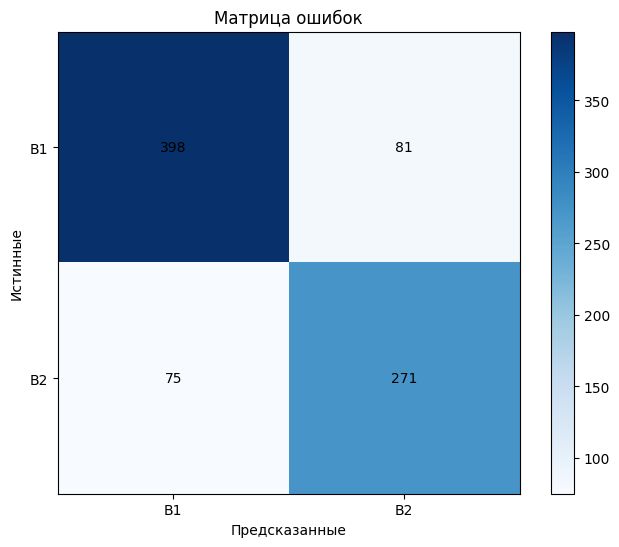

In [33]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['B1', 'B2'])
ax.set_yticklabels(['B1', 'B2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [34]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.8109
0.8109
0.8063
0.8111
0.1891
338.26


# C1/C2

In [35]:
df_C = df.copy()
df_C = df_C[df_C['label'] >= 5]
df_C['label'] = df_C['label'].map({5: 0, 6: 1})
df_C = df_C.reset_index()
df_C

,index,fragment,textbook-assigned cefr level,label,train_or_test
0,5990,Он увлёкся энтомологией ещё мальчиком и в детс...,5,0,0
1,5991,"Оказывается, доля этих людей в стране с 2003 г...",5,0,1
2,5992,Над заходом нависал балкон с белой же крашеной...,5,0,1
3,5993,"км, австралийской пустыне. Кстати, не по этой ...",5,0,1
4,5994,Кому-то не нравится постоянный шум в плацкарте...,5,0,1
...,...,...,...,...,...
1327,7317,Утечка мозгов стала ключевым трендом междунаро...,6,1,1
1328,7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,1,1
1329,7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,1,1
1330,7320,Mapillary использует программное обеспечение д...,6,1,1


In [36]:
model_C = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'C1', 1: 'C2'},
    label2id={'C1': 0, 'C2': 1}
)

model_C = model_C.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/sbert_large_nlu_ru and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [37]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_C)):
    if df_C['train_or_test'][i] == 1:
        train_texts.append(df_C['fragment'][i])
        train_labels.append(df_C['label'][i])
        
    else:
        val_texts.append(df_C['fragment'][i])
        val_labels.append(df_C['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 1057
Валидационная выборка: 275


In [38]:
trainer = Trainer(
    model=model_C,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [39]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.417500,0.299522
2,0.205200,0.231950
3,0.132100,0.348088


Обучение завершено за 121.96 секунд (0:02:01)


In [40]:
true_labels, predictions = evaluate_model(model_C, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.9273
F1 Micro: 0.9273
F1 Macro: 0.7800
F1 Weighted: 0.9207
MAE: 0.0727


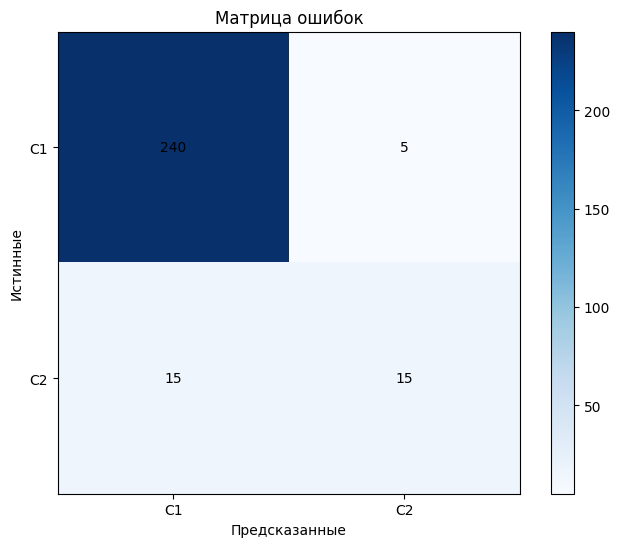

In [41]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['C1', 'C2'])
ax.set_yticklabels(['C1', 'C2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [42]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.9273
0.9273
0.7800
0.9207
0.0727
121.96


# Двухэтапная классификация

In [43]:
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1,0
2,На каждой двери красные плакаты и красные фона...,1,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6,1
7320,Mapillary использует программное обеспечение д...,6,6,1


In [44]:
df['label'] = df['label']-1


In [45]:
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,5,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,5,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,5,1
7320,Mapillary использует программное обеспечение д...,6,5,1


In [46]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)

In [47]:
true_labels, preds = evaluate_model(model, val_dataset, device)

In [48]:
labels=[]
i = 0
for pred, text in zip(preds, val_texts):
    if pred == 1:
        _, predictions = evaluate_model(model_A, [val_dataset[i]], device)
        labels.append(predictions[0])
    elif pred == 2:
        _, predictions = evaluate_model(model_B, [val_dataset[i]], device)
        labels.append(predictions[0]+2)
    else:
        _, predictions = evaluate_model(model_C, [val_dataset[i]], device)
        labels.append(predictions[0]+4)
    i+=1
    # print(predictions[0], len(labels))

In [49]:
set(labels)

{1, 2, 3, 4, 5, 6}

In [50]:
set(true_labels)

{1, 2, 3, 4, 5, 6}

In [51]:
labels[:10], true_labels[:10]

([1, 4, 4, 3, 5, 5, 3, 3, 3, 3], [1, 4, 4, 1, 4, 5, 3, 2, 3, 3])

In [52]:
accuracy = accuracy_score(true_labels, labels)
f1_micro = f1_score(true_labels, labels, average="micro")
f1_macro = f1_score(true_labels, labels, average="macro")
f1_weighted = f1_score(true_labels, labels, average="weighted")
mae = mean_absolute_error(true_labels, labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.6355
F1 Micro: 0.6355
F1 Macro: 0.6212
F1 Weighted: 0.6324
MAE: 0.4765


In [53]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
print(classification_report(true_labels, labels))

              precision    recall  f1-score   support

           1       0.77      0.73      0.75       153
           2       0.73      0.43      0.54       227
           3       0.64      0.69      0.66       475
           4       0.64      0.59      0.61       343
           5       0.54      0.75      0.63       237
           6       0.58      0.50      0.54        30

    accuracy                           0.64      1465
   macro avg       0.65      0.61      0.62      1465
weighted avg       0.65      0.64      0.63      1465

